# Gaussian Mixture Models (GMM)

The goal is to apply GMM for classification of our dataset. So, we need to model the class conditional distribution of samples of each one of the two classes, which represent true and false fingerprints, as a separate GMM:
$$
f_{\mathbf{X} \mid C}(\mathbf{X} \mid C = 1) \sim GMM(\mathbf{M}_1, \mathbf{S}_1, \mathbf{w}_1) \\[1.5em]
f_{\mathbf{X} \mid C}(\mathbf{X} \mid C = 0) \sim GMM(\mathbf{M}_0, \mathbf{S}_0, \mathbf{w}_0)
$$
So, after we found the best GMM for each class, we can write:
$$
f_{\mathbf{X} \mid C}(\mathbf{X} \mid C = 1) = \sum_{k = 1}^{K_1} w_{1, k} \mathcal{N}(\mathbf{x} \mid \mu_{1, k} \mathbf{\Sigma}_{1, k}) \\[1.5em]
f_{\mathbf{X} \mid C}(\mathbf{X} \mid C = 0) = \sum_{k = 1}^{K_0} w_{0, k} \mathcal{N}(\mathbf{x} \mid \mu_{0, k} \mathbf{\Sigma}_{0, k})
$$
Then, since we're dealing with a **binary** task, we can compute the log posterior ratio, and from it the log likelihood ratio, which we'll use a score, compare with the prior log odds of our target application, as threshold:
$$
\text{llr}(\mathbf{x}_t) = \log \frac{\sum_{k = 1}^{K_1} w_{1, k} \mathcal{N}(\mathbf{x} \mid \mu_{1, k} \mathbf{\Sigma}_{1, k})}{\sum_{k = 1}^{K_0} w_{0, k} \mathcal{N}(\mathbf{x} \mid \mu_{0, k} \mathbf{\Sigma}_{0, k})} \gtrless - \log \frac{\pi_T}{1- \pi_T}
$$
**The problem is that we need to pick the number of components for our classes, so the hyperparameters $K_1$, $K_0$, that achieve the best results.**. For now, we can resort to a Grid Search approach, trying with different distinct values and choosing the best pair $(K_1^*, K_0^*)$. <br>
In practice:
- we first train different GMM using different values for $K_1$ and $K_0$
- then we perform a Grid Search using the Validation Set, picking the tuple of values $(K_1^*, K_0^*)$ which lead to the **best $\text{min DCF}$ for out target application $\pi_T = 0.1$**.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from train_validation_split import splitTrainingValidation
from load_dataset import loadDataSet

DEBUG = False # Set to True for debugging with a small dataset

GMMPath = './models/GMM'
if not GMMPath in sys.path:
    sys.path.append(GMMPath)

import GMM

filename = "dataset/trainData.txt"
D, L = loadDataSet(filename, numFeatures=6)
if DEBUG:
    # Use only a subset of the data for debugging
    D = D[:, :100]
    L = L[:100]

(DTR, LTR), (DVAL, LVAL) = splitTrainingValidation(2.0/3.0, D, L)


print(f"DTR shape: {DTR.shape}")
print(f"DVAL shape: {DVAL.shape}")
print(f"LTR shape: {LTR.shape}")
print(f"LVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
DVAL shape: (6, 2000)
LTR shape: (4000,)
LVAL shape: (2000,)


Step 1: Parallelized training of all the different GMM models using different values for $K_0$, $K_1$:

In [43]:
import itertools
import pandas as pd
import seaborn as sns
from joblib import Parallel, delayed
from decisionModelsEvaluation import computeEmpiricalBayesRisk_Normalized, computeMinEmpiricalBayesRisk_Normalized

# -----------------------------------------------------------------------------
# STEP 1: PARALLEL TRAINING OF GMM MODELS
# -----------------------------------------------------------------------------

def train_single_gmm(data_subset, class_label, K, alpha, psiEig):
    """
    Worker function: trains a single GMM for a specific class and component number.
    This function is designed to be called in parallel by joblib.

    Parameters:
    - data_subset (numpy.array): The training data for a SINGLE class.
    - class_label (int): The label of the class (e.g., 0 or 1).
    - K (int): The target number of Gaussian components for the GMM.
    - alpha (float): The splitting factor for the LBG algorithm.
    - psiEig (float): The constraint for the eigenvalues of the covariance matrices.

    Returns:
    - tuple: A tuple containing (class_label,Kk, trained_model).
    trained_model is the GMM model trained on the data_subset, so list of gaussian components. Each one is a tuple of (weight, mean, covariance).
          weight: scalar
          mean: vector of size (D,)
          covariance: matrix of size (D, D)
    """
    print(f"Starting training: Class {class_label}, Components k={K}...")
    

    model, _ = GMM.train_GMM_EM_LBG(data_subset, targetNumberComponents=K, threshold_stop=1e-6, alpha=alpha, psiEig=psiEig)
    
    print(f"  -> Completed: Class {class_label}, k={k}")
    
    #return the identifier and the trained model itself
    return class_label, K, model


#We define different values of K to try for each class, up to 32. Remember K must be either 1 or an even number
k_values = [1, 2, 4, 8, 16, 32]


data_c0 = DTR[:, LTR == 0]
data_c1 = DTR[:, LTR == 1]

#to be faster, we put each job into a dictionary and then excute them in parallel.
#each job is a dictionary containing the parameters for one training run
training_jobs = []
for k in k_values:
    #add a job for class 0 with k components
    training_jobs.append({'data': data_c0, 'label': 0, 'k': k})
    #add a job for class 1 with k components
    training_jobs.append({'data': data_c1, 'label': 1, 'k': k})

print("--- Starting Parallel training of GMM Models with different values of K1, K0---")


#Execute all training jobs in parallel using all available CPU cores (n_jobs=-1)

trained_models_list = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_gmm)(
        job['data'], job['label'], job['k'], alpha=0.1, psiEig=0.01
    ) for job in training_jobs
)

gmm0_models = {}
gmm1_models = {}
for class_label, k, model in trained_models_list:
    if class_label == 0:
        gmm0_models[k] = model
    else:
        gmm1_models[k] = model


--- Starting Parallel training of GMM Models with different values of K1, K0---


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done   3 out of  12 | elapsed:    4.6s remaining:   14.1s
[Parallel(n_jobs=-1)]: Done   5 out of  12 | elapsed:    5.5s remaining:    7.7s
[Parallel(n_jobs=-1)]: Done   7 out of  12 | elapsed:    6.5s remaining:    4.6s
[Parallel(n_jobs=-1)]: Done   9 out of  12 | elapsed:    8.3s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done  12 out of  12 | elapsed:   22.8s finished


Step 2: Grid Search and Results table

In [44]:
# -----------------------------------------------------------------------------
# STEP 2: GRID SEARCH ON THE VALIDATION SET
# -----------------------------------------------------------------------------
results = []

print("\n--- Starting Grid Search on Validation Set ---")

appPriorTrue = 0.1 #target app prior for class 1

#Iterate over all combinations of pre-trained models for class 0 and class 1
for k0, k1 in itertools.product(k_values, k_values):
    #retrieve the pre-trained models from the dictionaries
    gmm0 = gmm0_models[k0]
    gmm1 = gmm1_models[k1]
    
    #compute the log-likelihood ratio (LLR) on the validation set
    llr = GMM.logpdf_GMM(DVAL, gmm1) - GMM.logpdf_GMM(DVAL, gmm0)

    #infer labels based on the log-likelihood ratio, as score, compare it with app prior log odds
    appPriorLogOdds = - np.log(appPriorTrue / (1.0 - appPriorTrue))
    PVAL = np.where(llr > appPriorLogOdds, 1, 0)

    #compute error rate on the validation set
    errorRate = np.mean(PVAL != LVAL)
    
    #compute minDCF and DCF
    minDCF = computeMinEmpiricalBayesRisk_Normalized(llr, LVAL, appPriorTrue, 1.0, 1.0)
    DCF = computeEmpiricalBayesRisk_Normalized(llr, LVAL, appPriorTrue, 1.0, 1.0)
    
    #Store the result for this (k0, k1) pair
    results.append((k0, k1, errorRate, minDCF, DCF))

#find the best combination of (k0, k1) based on the lowest minDCF
best_k0, best_k1, best_errorRate, best_minDCF, best_DCF = min(results, key=lambda x: x[3])
print(f"\nBest combination found (choosing minDCF): K0={best_k0}, K1={best_k1}, Error Rate={best_errorRate * 100: .2f}%, with minDCF={best_minDCF:.4f}, DCF={best_DCF:.4f}")


--- Starting Grid Search on Validation Set ---

Best combination found (choosing minDCF): K0=1, K1=16, Error Rate= 9.95%, with minDCF=0.1495, DCF=0.2055


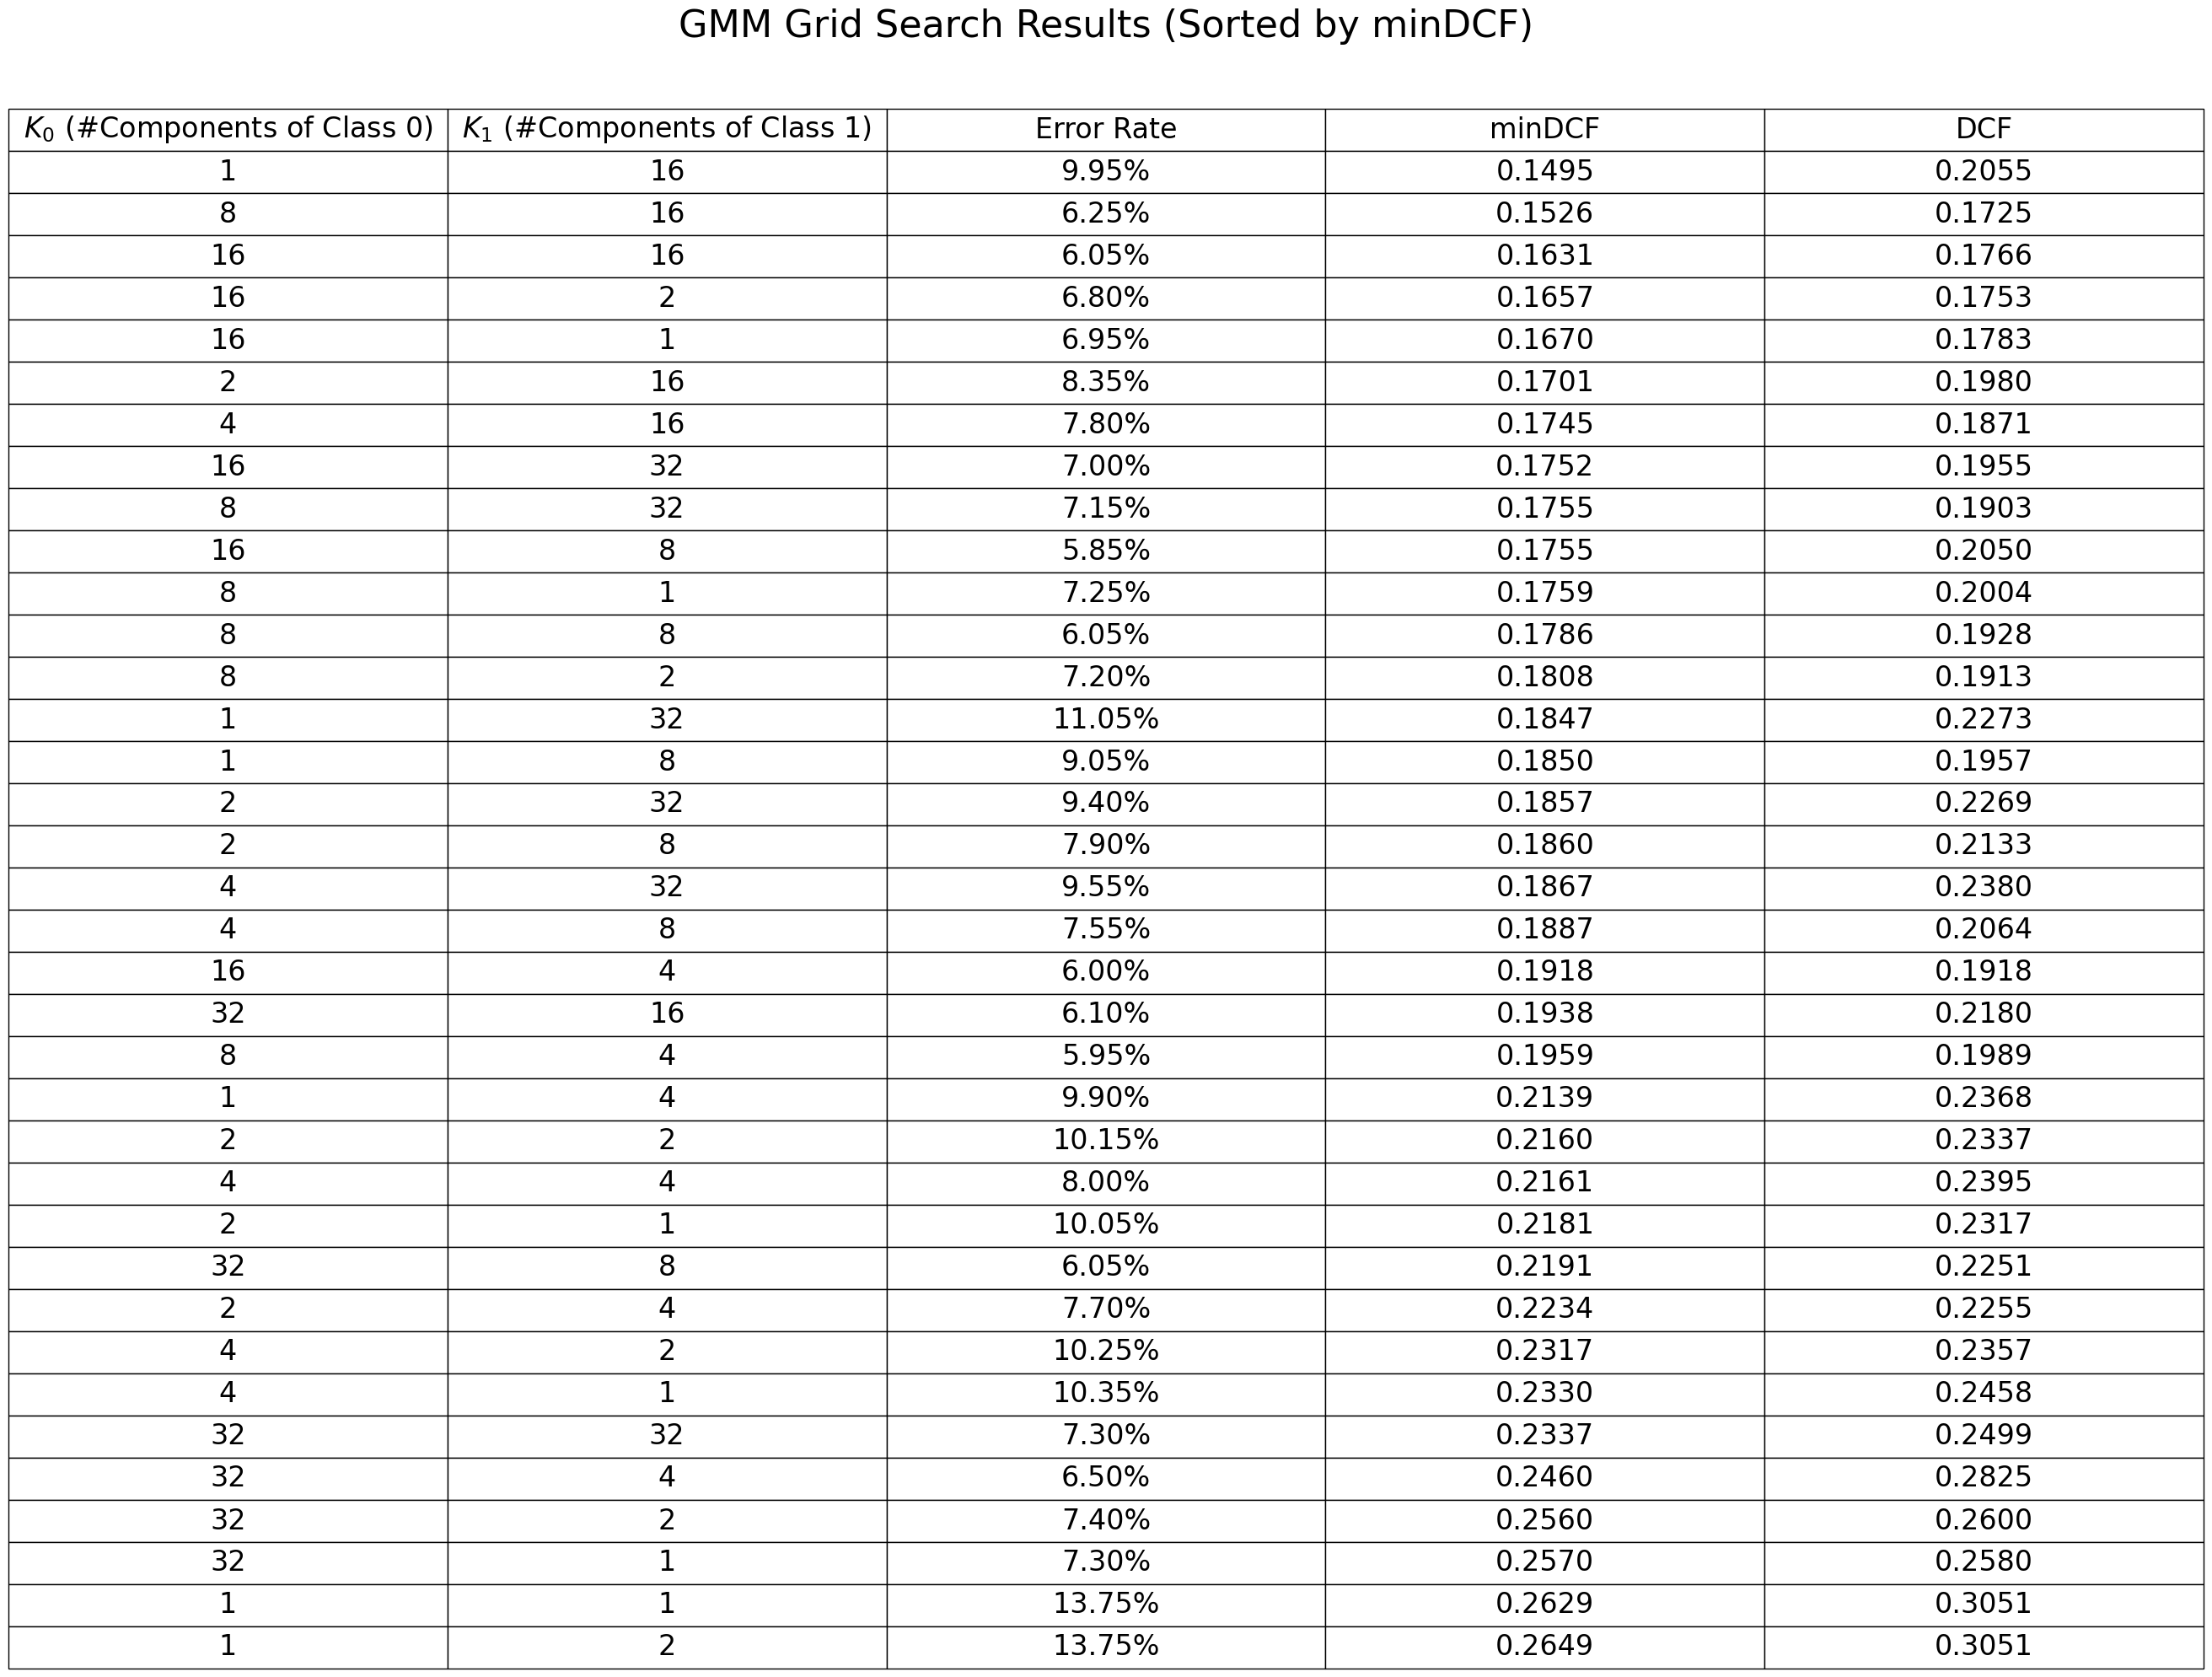

In [46]:
#sort results by minDCF to show the best combinations at the top
sorted_results = sorted(results, key=lambda x: x[3])


table_data = []
for k0_res, k1_res, ErrorRate_res, minDCF_res, DCF_res in sorted_results:
    table_data.append([k0_res, k1_res, f"{ErrorRate_res * 100:.2f}%", f"{minDCF_res:.4f}", f"{DCF_res:.4f}"])


fig, ax = plt.subplots(figsize=(8, 10)) 
ax.axis('tight')
ax.axis('off')


col_labels = ['$K_0$ (#Components of Class 0)', '$K_1$ (#Components of Class 1)', 'Error Rate', 'minDCF', 'DCF']

table = ax.table(cellText=table_data, colLabels=col_labels, loc='center', cellLoc='center')


table.auto_set_font_size(False)
table.set_fontsize(24)
table.scale(4.2, 3) 

plt.title('GMM Grid Search Results (Sorted by minDCF)', fontsize=32, pad=450)
plt.show()